In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.interpolate import UnivariateSpline
import pandas as pd
legend_font = 10
axes_font = 12
label_font = 11
plot_linewidth = 2
axes_linewidth = 0.9

In [2]:
# Calculate RI
def getRI(wavelength, temperature):
    """
    wavelength : um
    temperature : degC
    Returns:
        n_x, n_y, n_z
    """

    delta_T = temperature - 20

    # Sellmeier equations
    n_x = np.sqrt(
        2.4542
        + 0.01125 / (wavelength**2 - 0.01135)
        - 0.01388 * wavelength**2
    )

    n_y = np.sqrt(
        2.5390
        + 0.01277 / (wavelength**2 - 0.01189)
        - 0.01849 * wavelength**2
        + 4.3025e-5 * wavelength**4
        - 2.9131e-5 * wavelength**6
    )

    n_z = np.sqrt(
        2.5865
        + 0.01310 / (wavelength**2 - 0.01223)
        - 0.01862 * wavelength**2
        + 4.5778e-5 * wavelength**4
        - 3.2526e-5 * wavelength**6
    )

    # Temperature corrections
    delta_nx = (
        (-3.76 * wavelength + 2.30)
        * 1e-6
        * (delta_T + 29.13e-3 * delta_T**2)
    )

    delta_ny = (
        (6.01 * wavelength - 19.40)
        * 1e-6
        * (delta_T - 32.89e-4 * delta_T**2)
    )

    delta_nz = (
        (1.50 * wavelength - 9.70)
        * 1e-6
        * (delta_T - 74.49e-4 * delta_T**2)
    )

    n_x += delta_nx
    n_y += delta_ny
    n_z += delta_nz

    return np.real(n_x), np.real(n_y), np.real(n_z)

## Type I phase matching 
$$ n_z+n_z \rightarrow n_y$$

In [3]:
# Type I phase mismatch function 
def phase_mismatch_typeI(wavelength, temperature,phi):
    """
    Type-I SHG:
    z + z -> y

    Output in meter inverse
    """
    lambda_shg = wavelength / 2
    phi= np.deg2rad(phi)
    n_x_shg, n_y_shg, _ = getRI(lambda_shg, temperature)
    _, _, n_z_fundamental = getRI(wavelength, temperature)

    # Ordinary refractive index
    no=n_z_fundamental
    ne=1/(np.sqrt((np.cos(phi)/n_y_shg)**2+(np.sin(phi)/n_x_shg)**2))
    return 1e6*(4*np.pi/wavelength)*(no - ne)

## Type II phase matching 
$$ n_{x}+n_{y} \rightarrow n_{x}$$

In [4]:
# Type II phase mismatch function
def phase_mismatch_typeII(wavelength, temperature,theta):
    """
    Type-II SHG:
    x + y -> x

    Output in m inverse 
    """
    theta= np.deg2rad(theta)
    lambda_shg = wavelength / 2

    n_x_shg, _, n_z_shg = getRI(lambda_shg, temperature)
    n_x_fundamental, n_y_fundamental, n_z_fundamental = getRI(wavelength, temperature)

    no=n_y_fundamental
    ne_fundamental=1/(np.sqrt((np.cos(theta)/n_x_fundamental)**2+(np.sin(theta)/n_z_fundamental)**2))
    ne_shg=1/(np.sqrt((np.cos(theta)/n_x_shg)**2+(np.sin(theta)/n_z_shg)**2))
    return 1e6*(-2 * ne_shg + (no + ne_fundamental))*(2*np.pi/wavelength)

In [5]:
# PM temperature calculation function

def PM_temp(wavelength,PM_type):
    temperatures = []

    if PM_type=="Type-I":
        for lam in wavelength:
            sol = root_scalar(
                lambda T: phase_mismatch_typeI(lam, T,phi=0),
                bracket=[-20, 300],
                method="brentq",)

            temperatures.append(sol.root)
    if PM_type=="Type-II":
        for lam in wavelength:
            sol = root_scalar(
                lambda T: phase_mismatch_typeII(lam, T,theta=0),
                bracket=[-20, 50],
                method="brentq",)

            temperatures.append(sol.root)
    temperatures = np.array(temperatures)
    return temperatures
        

In [6]:
# Angular acceptance bandwidth calculation for type-I
wavelengths=np.linspace(1.06,1.198,50)
temperatures=PM_temp(wavelength=wavelengths,PM_type="Type-I")

L=25e-3         # LBO crystal length in meters
acc_bndwd=[]   # Phase matching bandwidth in um
PM_phi=[]

# for i in range(len(wavelength1)):
for i in range(len(wavelengths)):
    sol = root_scalar(lambda p: phase_mismatch_typeI(wavelengths[i], 25, phi=p),bracket=[0, 90], method="brentq")
    PM_phi_val = sol.root
    phi_scan = np.linspace(PM_phi_val-0.8, PM_phi_val+0.8, 1000)

    dk = np.array([phase_mismatch_typeI(wavelengths[i], 25,phi=t) for t in phi_scan])

    

    
    eff = (np.sinc(dk*L/(2*np.pi)))**2
    half_value = np.max(eff)*0.5
    spline = UnivariateSpline(phi_scan, eff-half_value, s=0)
    roots = spline.roots()  # Returns points where the spline crosses 0
    
    acc_bndwd_val = roots[1] - roots[0]
    
    acc_bndwd.append(acc_bndwd_val)
    PM_phi.append(PM_phi_val)
    
acc_bndwd = np.array(acc_bndwd)
acc_bndwd_mrad=np.deg2rad(acc_bndwd)*1e3
PM_phi=np.array(PM_phi)




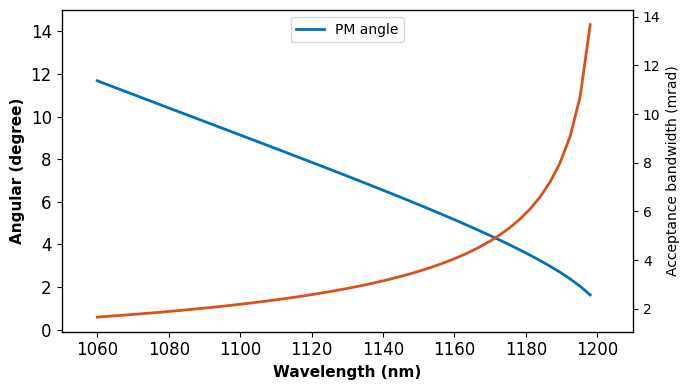

In [7]:

# in mrad.cm

# Plot functions

fig, ax = plt.subplots(figsize=(7, 4))


ax.plot(
    wavelengths * 1e3,
    PM_phi,
    color="#0072BD",
    linewidth=plot_linewidth,
    label="PM angle",
)


ax.set_xlabel("Wavelength (nm)",fontsize=label_font,fontweight="bold",)

ax.set_ylabel( "Angular (degree)",fontsize=label_font,fontweight="bold",)

ax2 = ax.twinx()
ax2.plot(
    wavelengths * 1e3,
    acc_bndwd_mrad,
    color=(0.8500, 0.3250, 0.0980),
    linewidth=plot_linewidth,
    label="Acceptance bandwidth",
)
ax2.set_ylabel("Acceptance bandwidth (mrad)")

ax.set_xlim([1050, 1210])
ax.set_ylim([-0.1, 15])

ax.tick_params(labelsize=axes_font)

for spine in ax.spines.values():
    spine.set_linewidth(axes_linewidth)
ax.legend(fontsize=legend_font,loc="upper center",ncol=2,)
plt.savefig("LBO PM angle.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

In [8]:
print((np.deg2rad(1.0)*1e3))

17.453292519943297


In [9]:
# Phase matching temperature calculation
# Type-I
wavelength1 = np.linspace(1.06, 1.6, 50)
temperatures1 = PM_temp(wavelength=wavelength1,PM_type="Type-I")


# Type-II
wavelength2 = np.linspace(1.15, 1.45, 50)

temperatures2 =PM_temp(wavelength=wavelength2,PM_type="Type-II")

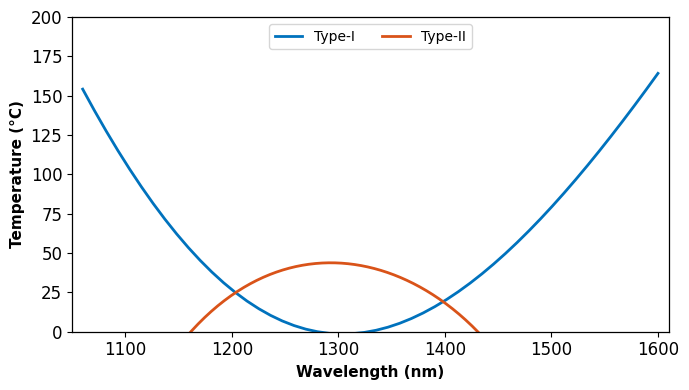

In [10]:
# Plot functions

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    wavelength1 * 1e3,
    temperatures1,
    color="#0072BD",
    linewidth=plot_linewidth,
    label="Type-I",
)


ax.plot(
    wavelength2 * 1e3,
    temperatures2,
    color=(0.8500, 0.3250, 0.0980),
    linewidth=plot_linewidth,
    label="Type-II",
)

ax.set_xlabel(
    "Wavelength (nm)",
    fontsize=label_font,
    fontweight="bold",
)

ax.set_ylabel(
    "Temperature (°C)",
    fontsize=label_font,
    fontweight="bold",
)

ax.set_xlim([1050, 1610])
ax.set_ylim([0, 200])

ax.tick_params(labelsize=axes_font)

for spine in ax.spines.values():
    spine.set_linewidth(axes_linewidth)

ax.legend(
    fontsize=legend_font,
    loc="upper center",
    ncol=2,
)

plt.tight_layout()
plt.show()

In [11]:

L=25e-3         # LBO crystal length in meters
linewidth1=[]   # Phase matching bandwidth in um
wavelength1=np.linspace(1.060,1.205,100)  # Wavelengths in um
temperatures1=PM_temp(wavelength=wavelength1,PM_type="Type-I")
# for i in range(len(wavelength1)):
for i in range(len(wavelength1)):
    lambda1=wavelength1[i]
    T=temperatures1[i]
    # print(lambda1)
    # print(T)
    lam_scan = np.linspace(lambda1-0.005, lambda1+0.005, 1000)

    dk = np.array([phase_mismatch_typeI(l, T,phi=0) for l in lam_scan])

    eff = (np.sinc(dk*L/(2*np.pi)))**2
    half_value = np.max(eff)*0.5
    spline = UnivariateSpline(lam_scan, eff-half_value, s=0)
    roots = spline.roots()  # Returns points where the spline crosses 0
    linewidth_val = roots[1] - roots[0]
    # print(len(roots))
    linewidth1.append(linewidth_val)
    
linewidth1 = np.array(linewidth1)
print(linewidth1[0]*1e3)


1.4885329922471602


In [12]:

linewidth2=[]
wavelength2=np.linspace(1.2,1.26,100)
temperatures2=PM_temp(wavelength=wavelength2,PM_type="Type-II")
# for i in range(len(wavelength1)):
for i in range(len(wavelength2)):
    lambda1=wavelength2[i]
    T=temperatures2[i]
    # print(lambda1)
    # print(T)
    lam_scan = np.linspace(lambda1-0.05, lambda1+0.05, 1000)

    dk = np.array([phase_mismatch_typeII(l, T,theta=0) for l in lam_scan])

    eff = (np.sinc(dk*L/(2*np.pi)))**2
    half_value = np.max(eff)*0.5
    spline = UnivariateSpline(lam_scan, eff-half_value, s=0)
    roots = spline.roots()  # Returns points where the spline crosses 0
    linewidth_val = roots[1] - roots[0]
    linewidth2.append(linewidth_val)
    # plt.plot(eff)

    
linewidth2 = np.array(linewidth2)

# plt.ylim(0,10)


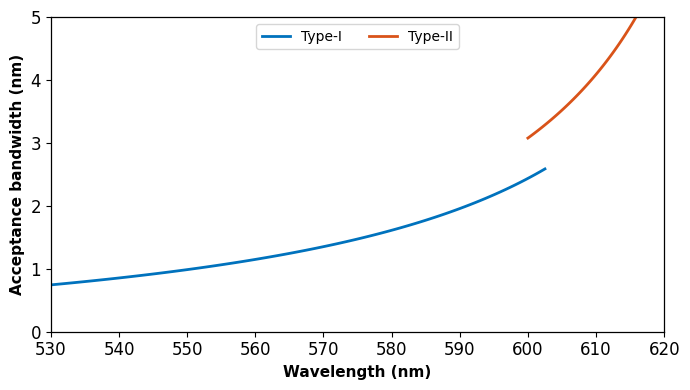

In [13]:

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    wavelength1* 0.5 * 1e3,
    linewidth1* 0.5 *1e3,
    color="#0072BD",
    linewidth=plot_linewidth,
    label="Type-I",
)


ax.plot(
    wavelength2 * 0.5 * 1e3,
    linewidth2* 0.5 * 1e3,
    color=(0.8500, 0.3250, 0.0980),
    linewidth=plot_linewidth,
    label="Type-II",
)

ax.set_xlabel(
    "Wavelength (nm)",
    fontsize=label_font,
    fontweight="bold",
)

ax.set_ylabel(
    "Acceptance bandwidth (nm)",
    fontsize=label_font,
    fontweight="bold",
)

ax.set_xlim([530, 620])
ax.set_ylim([0, 5])

ax.tick_params(labelsize=axes_font)

for spine in ax.spines.values():
    spine.set_linewidth(axes_linewidth)

ax.legend(
    fontsize=legend_font,
    loc="upper center",
    ncol=2,
)

plt.tight_layout()
plt.show()

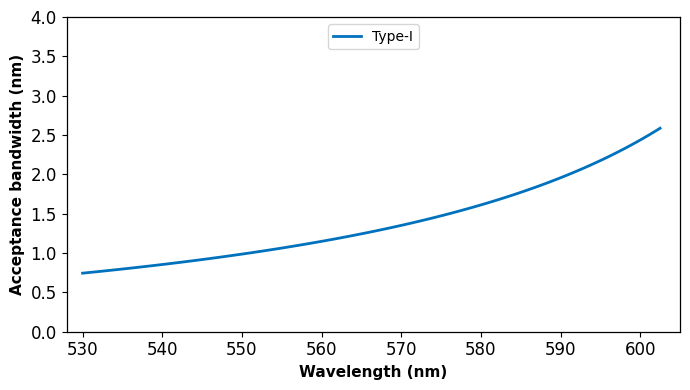

In [14]:

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    wavelength1* 0.5 * 1e3,
    linewidth1* 0.5 *1e3,
    color="#0072BD",
    linewidth=plot_linewidth,
    label="Type-I",
)

ax.set_xlabel(
    "Wavelength (nm)",
    fontsize=label_font,
    fontweight="bold",
)

ax.set_ylabel(
    "Acceptance bandwidth (nm)",
    fontsize=label_font,
    fontweight="bold",
)

ax.set_xlim([528, 605])
ax.set_ylim([0, 4])

ax.tick_params(labelsize=axes_font)

for spine in ax.spines.values():
    spine.set_linewidth(axes_linewidth)

ax.legend(
    fontsize=legend_font,
    loc="upper center",
    ncol=2,
)
fig.savefig(

    "acceptance_bandwidth.pdf",

    bbox_inches="tight",

    dpi=300

)
plt.tight_layout()
plt.show()
